<a href="https://colab.research.google.com/github/Fake-Chemist26/VibeCheck-/blob/main/VibeCheck%E2%84%A2_Workbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Load and Transpose Data
df = pd.read_csv('Fruit_purees_FTIR.csv', index_col=0).T #DONT FORGET TO CHANGE FILE NAME

# Identify the column containing string labels (e.g., 'raspberry')
# Based on the error, 'Wavenumbers' column in the transposed df contains these strings.
# We will use this as our target variable 'y'.
y_labels = df['Wavenumbers'].values

# Identify spectral data (numerical columns)
# Drop the non-numeric 'Wavenumbers' column and potentially other label columns
# Filter by trying to convert column names to float. If successful, it's a spectral column.
spectral_columns = []
for col in df.columns:
    try:
        float(col)
        spectral_columns.append(col)
    except ValueError:
        pass

X_df = df[spectral_columns]

# Ensure all data in X_df is numeric and convert to float
X_data = X_df.values.astype(float)

# 2. Preprocessing: Savitzky-Golay Smoothing
# Window size must be odd, polyorder is usually 2 or 3
cleaned_spectra = savgol_filter(X_data, window_length=11, polyorder=3)

# 3. Scaling
scaler = StandardScaler()
X = scaler.fit_transform(cleaned_spectra)

# 4. Reshape for a Convolutional Neural Network (Samples, Steps, Features)
# Since it's 1-dimensional, Features = 1
X = X.reshape(X.shape[0], X.shape[1], 1)

# 5. Split (y is now defined and encoded)
# Encode y_labels into numerical format
le = LabelEncoder()
y = le.fit_transform(y_labels)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter, find_peaks
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models


# Wavenumber axis (Change this to match your specific spectrometer's resolution)
# Example: 4000 to 400 cm-1
WAVENUMBERS = np.linspace(4000, 400, 3601)

class IR_Smart_Labeler:
    def __init__(self, wavenumber_axis):
        self.wn = wavenumber_axis

        # DEFINING THE RULES (Based on your provided table)
        # Format: (Min_WN, Max_WN, Min_Intensity, Shape_Check)
        # Min_Intensity: 0.0 to 1.0 (assuming normalized data)
        self.rules = {
            # --- Zone 1: Hydrogens ---
            'Alcohol_Free':     (3610, 3640, 0.5, 'sharp'),
            'Alcohol_HBond':    (3200, 3500, 0.4, 'broad'),
            'Amine_Primary':    (3250, 3400, 0.2, None), # Look for doublet manually if needed
            'Acid_OH':          (2500, 3300, 0.3, 'broad'),
            'Alkyne_H':         (3270, 3330, 0.5, 'sharp'),
            'Aromatic_CH':      (3000, 3100, 0.2, None),
            'Alkene_CH':        (3000, 3100, 0.2, None),
            'Alkane_CH':        (2850, 3000, 0.4, None),
            'Aldehyde_CH':      (2695, 2830, 0.2, None),

            # --- Zone 2: Triples ---
            'Nitrile':          (2210, 2260, 0.3, 'sharp'),
            'Alkyne_Triple':    (2100, 2260, 0.1, None), # Weak

            # --- Zone 3: Doubles (The Danger Zone) ---
            # We define a generic 'Carbonyl' bucket first, then refine later
            'Carbonyl_Gen':     (1665, 1760, 0.6, 'sharp'),
            'Alkene_C=C':       (1640, 1680, 0.3, None),
            'Nitro':            (1475, 1550, 0.6, None),
            'Aromatic_Ring':    (1400, 1600, 0.3, None),

            # --- Zone 4: Fingerprint ---
            'Ether_Est_Acid_CO':(1000, 1320, 0.6, None), # C-O stretch
            'Alkyl_Halide':     (550, 850, 0.3, None),
            'Alkene_Bend':      (650, 1000, 0.5, None)
        }

    def _has_peak(self, spectrum, rule_name):
        """Helper to check if a specific peak exists in the spectrum."""
        min_w, max_w, min_int, shape = self.rules[rule_name]

        # 1. Mask the spectrum to the specific region
        mask = (self.wn >= min_w) & (self.wn <= max_w) if self.wn[0] < self.wn[-1] else (self.wn <= min_w) & (self.wn >= max_w)
        region_data = spectrum[mask]

        if len(region_data) == 0: return False

        # 2. Find max intensity in this region
        max_val = np.max(region_data)

        # 3. Basic Check
        if max_val < min_int:
            return False

        # 4. Shape Check (Optional implementation for Broad/Sharp)
        # Using peak_widths from scipy would go here for advanced shape logic
        return True

    def label_spectrum(self, spectrum):
        """
        Applies logic to generate the One-Hot Label Vector.
        Returns a dictionary of confirmed functional groups.
        """
        labels = {}

        # 1. First Pass: Check everything independently
        features = {k: self._has_peak(spectrum, k) for k in self.rules.keys()}

        # 2. Second Pass: The TIE-BREAKER Logic (Contextual Chemistry)

        # --- Carbonyl Logic Tree ---
        has_CO = features['Carbonyl_Gen']

        if has_CO:
            # A. Carboxylic Acid? (Needs C=O AND Broad O-H)
            if features['Acid_OH']:
                labels['Carboxylic_Acid'] = 1
                features['Alcohol_HBond'] = 0 # Don't double count the OH

            # B. Aldehyde? (Needs C=O AND the Fermi Doublet C-H)
            elif features['Aldehyde_CH']:
                labels['Aldehyde'] = 1

            # C. Ester? (Needs C=O AND strong C-O stretch)
            elif features['Ether_Est_Acid_CO']:
                labels['Ester'] = 1

            # D. Amide? (Needs C=O is low freq <1690 AND N-H exists)
            # (Simplified check)
            elif features['Amine_Primary']:
                labels['Amide'] = 1

            # E. Ketone (The default if C=O exists but nothing else specific matches)
            else:
                labels['Ketone'] = 1

        # --- Other Groups ---
        if features['Alcohol_Free'] or features['Alcohol_HBond']: labels['Alcohol'] = 1
        if features['Nitrile']: labels['Nitrile'] = 1
        if features['Nitro']: labels['Nitro'] = 1
        if features['Aromatic_Ring'] or features['Aromatic_CH']: labels['Aromatic'] = 1
        if features['Alkene_C=C'] or features['Alkene_CH']: labels['Alkene'] = 1
        if features['Alkyne_Triple'] or features['Alkyne_H']: labels['Alkyne'] = 1
        if features['Amine_Primary']: labels['Amine'] = 1

        return labels

# Example usage
# labeler = IR_Smart_Labeler(wavenumber_axis=df.columns.values)

In [ ]:
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

class IR_Smart_Labeler:
    def __init__(self, wavenumber_axis):
        self.wn = wavenumber_axis
        # Universal Rules with high sensitivity (0.05 threshold)
        self.rules = {
            'Alcohol': (3200, 3650, 0.05, 'broad'),
            'Carboxylic_Acid': (2500, 3300, 0.05, 'broad'),
            'Amine/Amide': (3300, 3500, 0.05, None),
            'Alkyne': (2100, 2260, 0.05, None),
            'Nitrile': (2210, 2260, 0.05, 'sharp'),
            'Carbonyl': (1650, 1800, 0.05, 'sharp'),
            'Alkene': (1600, 1680, 0.05, None),
            'Aromatic': (1400, 1600, 0.05, None),
            'Nitro': (1500, 1570, 0.05, None),
            'Ether/Ester': (1000, 1300, 0.05, None),
            'Alkyl_Halide': (500, 850, 0.05, None)
        }

    def _has_peak(self, spectrum, rule_name):
        min_w, max_w, min_int, shape = self.rules[rule_name]
        mask = (self.wn >= min_w) & (self.wn <= max_w)
        region_data = spectrum[mask]
        if len(region_data) == 0: return False
        return np.max(region_data) >= min_int

    def label_spectrum(self, spectrum):
        return {k: 1 if self._has_peak(spectrum, k) else 0 for k in self.rules.keys()}

def run_ir_training_pipeline(csv_path):
    df = pd.read_csv(csv_path)
    spectral_columns = [col for col in df.columns if col.replace('.','',1).isdigit()]
    wavenumbers = np.array([float(col) for col in spectral_columns])
    X_raw = df[spectral_columns].apply(pd.to_numeric, errors='coerce').dropna().values
    X_smooth = savgol_filter(X_raw, window_length=11, polyorder=3, axis=1)
    X_scaled = MinMaxScaler().fit_transform(X_smooth.T).T
    labeler = IR_Smart_Labeler(wavenumbers)
    CLASSES = list(labeler.rules.keys())
    y = np.array([[labeler.label_spectrum(s).get(c, 0) for c in CLASSES] for s in X_scaled])
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
    model = models.Sequential([
        layers.Input(shape=(X_train.shape[1], 1)),
        layers.Conv1D(64, 11, activation='relu'),
        layers.GlobalMaxPooling1D(),
        layers.Dense(128, activation='relu'),
        layers.Dense(len(CLASSES), activation='sigmoid')
    ]) #^^^CROSS ENTROPY SECTION (GOOD GOD THIS TOOK FOREVER)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])
    history = model.fit(X_train, y_train, epochs=20, batch_size=16, verbose=0)
    return model, CLASSES, X_test, y_test, wavenumbers, history

model, CLASSES, X_test, y_test, wavenumbers_global, history = run_ir_training_pipeline('Fruit_purees_FTIR.csv')
print('Final High-Sensitivity Universal Model Retrained.')

In [ ]:
import pandas as pd
import numpy as np

# 1. Prepare data and labels
# Standardizing column detection based on the 'Wavenumbers' column in your df
spectral_cols = [c for c in df.columns if any(char.isdigit() for char in str(c)) and '.' in str(c)]

# Get the fruit category for each row based on the 'Wavenumbers' column strings
def get_category(row_val):
    label = str(row_val).lower().strip()
    if 'raspberry' in label: return 'Raspberry'
    if 'strawberry' in label: return 'Strawberry'
    return 'Neither'

# The transposed df has labels in the 'Wavenumbers' column
df['Fruit_Category'] = df['Wavenumbers'].apply(get_category)

# Initialize labeler with current wavenumbers
labeler = IR_Smart_Labeler(wavenumber_axis=np.array([float(c) for c in spectral_cols]))

# Calculate presence for each spectrum
results = []
for idx, row in df.iterrows():
    # Normalize row data for the labeler
    spec = pd.to_numeric(row[spectral_cols], errors='coerce').fillna(0).values
    norm_spec = (spec - spec.min()) / (spec.max() - spec.min() + 1e-9)

    detected = labeler.label_spectrum(norm_spec)
    detected['Fruit_Category'] = row['Fruit_Category']
    results.append(detected)

# Create summary table
counts_df = pd.DataFrame(results).groupby('Fruit_Category').sum()
print("Occurrence of Functional Groups by Category:")
display(counts_df)

Occurrence of Functional Groups by Category:


,Alcohol,Carboxylic_Acid,Amine/Amide,Alkyne,Nitrile,Carbonyl,Alkene,Aromatic,Nitro,Ether/Ester,Alkyl_Halide
Fruit_Category,,,,,,,,,,,
Neither,0,0,0,0,0,450,211,473,248,473,0
Raspberry,0,0,0,0,0,159,156,159,129,159,0
Strawberry,0,0,0,0,0,349,296,351,246,351,0


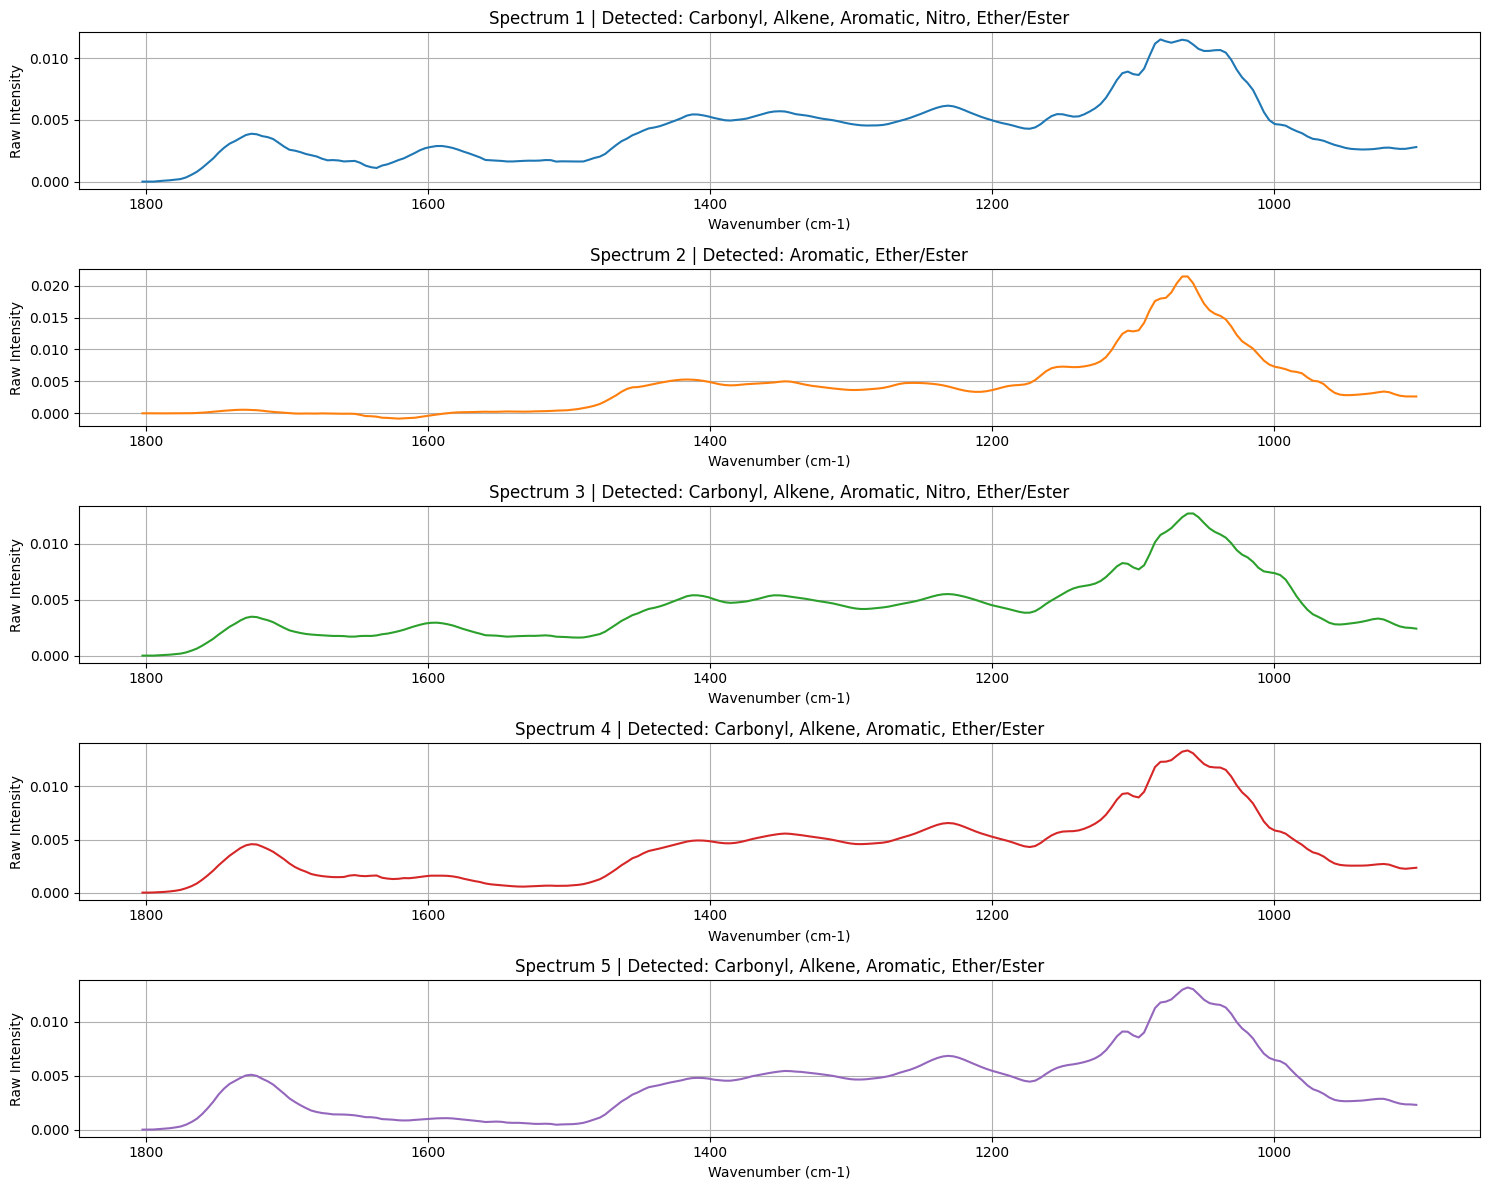

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. Identify spectral columns and correct wavenumber axis for raw data
spectral_columns = [col for col in df.columns if col.replace('.','',1).isdigit()]
wn_raw = np.array([float(col) for col in spectral_columns])

# 2. Re-instantiate labeler with the axis matching X_data
labeler_raw = IR_Smart_Labeler(wavenumber_axis=wn_raw)

plt.figure(figsize=(15, 12))
num_plots = min(5, X_data.shape[0])

for i in range(num_plots):
    plt.subplot(num_plots, 1, i + 1)

    # Use raw data for plotting
    spectrum_raw = X_data[i]

    # Normalize only for the labeler's thresholds
    scaler = MinMaxScaler()
    spectrum_norm = scaler.fit_transform(spectrum_raw.reshape(-1, 1)).flatten()

    # Get detected groups using the aligned labeler
    detected = labeler_raw.label_spectrum(spectrum_norm)
    present = [k for k, v in detected.items() if v == 1]

    # Plot raw spectrum with correct x-axis
    plt.plot(wn_raw, spectrum_raw, color='C'+str(i))

    # Create annotation
    title_text = f"Spectrum {i+1} | Detected: {', '.join(present)}" if present else f"Spectrum {i+1} | No Groups Detected"
    plt.title(title_text)

    plt.xlabel("Wavenumber (cm-1)")
    plt.ylabel("Raw Intensity")
    plt.gca().invert_xaxis()
    plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
# If you also had validation data, you could plot validation loss like this:
# plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Binary Cross-Entropy Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Prepare raw numeric data
spectral_columns = [col for col in df.columns if col.replace('.','',1).isdigit()]
wn_diag = np.array([float(col) for col in spectral_columns])
X_raw_diag = df[spectral_columns].apply(pd.to_numeric, errors='coerce').dropna().values

# 2. Normalize
X_scaled_diag = MinMaxScaler().fit_transform(X_raw_diag.T).T

# 3. Check every rule in the IR_Smart_Labeler
labeler_diag = IR_Smart_Labeler(wavenumber_axis=wn_diag)
results = []

for i in range(min(10, len(X_scaled_diag))):
    row_results = {'Sample': i}
    for group, (low, high, thresh, shape) in labeler_diag.rules.items():
        mask = (wn_diag >= min(low, high)) & (wn_diag <= max(low, high))
        max_val = np.max(X_scaled_diag[i][mask]) if any(mask) else 0.0
        row_results[group] = round(max_val, 4)
    results.append(row_results)

diagnostic_full_df = pd.DataFrame(results)
print("Full Diagnostic: Max Intensities for ALL Functional Groups (Threshold = 0.05):")
display(diagnostic_full_df)

Full Diagnostic: Max Intensities for ALL Functional Groups (Threshold = 0.05):


,Sample,Alcohol,Carboxylic_Acid,Amine/Amide,Alkyne,Nitrile,Carbonyl,Alkene,Aromatic,Nitro,Ether/Ester,Alkyl_Halide
0,0,0.0,0.0,0.0,0.0,0.0,0.3368,0.2358,0.4726,0.1847,1.0,0.0
1,1,0.0,0.0,0.0,0.0,0.0,0.0623,0.0367,0.2751,0.0586,1.0,0.0
2,2,0.0,0.0,0.0,0.0,0.0,0.2736,0.2261,0.4245,0.1642,1.0,0.0
3,3,0.0,0.0,0.0,0.0,0.0,0.3408,0.1232,0.3670,0.0812,1.0,0.0
4,4,0.0,0.0,0.0,0.0,0.0,0.3859,0.1240,0.3640,0.0626,1.0,0.0
5,5,0.0,0.0,0.0,0.0,0.0,0.2279,0.0870,0.3265,0.0575,1.0,0.0
6,6,0.0,0.0,0.0,0.0,0.0,0.3327,0.1093,0.3609,0.0685,1.0,0.0
7,7,0.0,0.0,0.0,0.0,0.0,0.6215,0.2362,0.4813,0.1176,1.0,0.0
8,8,0.0,0.0,0.0,0.0,0.0,0.3739,0.1205,0.3505,0.0491,1.0,0.0
9,9,0.0,0.0,0.0,0.0,0.0,0.1706,0.0725,0.3057,0.0437,1.0,0.0


In [ ]:
from google.colab import data_table
# Use Colab's interactive data table instead of Sheets to avoid credential errors
data_table.DataTable(diagnostic_full_df, num_rows_per_page=10)

,Sample,Alcohol,Carboxylic_Acid,Amine/Amide,Alkyne,Nitrile,Carbonyl,Alkene,Aromatic,Nitro,Ether/Ester,Alkyl_Halide
0,0,0.0,0.0,0.0,0.0,0.0,0.3368,0.2358,0.4726,0.1847,1.0,0.0
1,1,0.0,0.0,0.0,0.0,0.0,0.0623,0.0367,0.2751,0.0586,1.0,0.0
2,2,0.0,0.0,0.0,0.0,0.0,0.2736,0.2261,0.4245,0.1642,1.0,0.0
3,3,0.0,0.0,0.0,0.0,0.0,0.3408,0.1232,0.3670,0.0812,1.0,0.0
4,4,0.0,0.0,0.0,0.0,0.0,0.3859,0.1240,0.3640,0.0626,1.0,0.0
5,5,0.0,0.0,0.0,0.0,0.0,0.2279,0.0870,0.3265,0.0575,1.0,0.0
6,6,0.0,0.0,0.0,0.0,0.0,0.3327,0.1093,0.3609,0.0685,1.0,0.0
7,7,0.0,0.0,0.0,0.0,0.0,0.6215,0.2362,0.4813,0.1176,1.0,0.0
8,8,0.0,0.0,0.0,0.0,0.0,0.3739,0.1205,0.3505,0.0491,1.0,0.0
9,9,0.0,0.0,0.0,0.0,0.0,0.1706,0.0725,0.3057,0.0437,1.0,0.0
